# Lectutorial 3: Design choices and hyperparameter tuning

1. Activation functions
2. Weights initialisation
3. Regularisation
4. Hyper-parameter tuning (learning rate, number of neurons, layers, ...)
5. Learning rate schedules
6. Batch-norm
7. Faster optimisers

In [690]:
from copy import deepcopy
import numpy as np
import torch
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import optuna
from functools import partial

## Coding Time 1: Activation functions & regularisation

### 1. Activation functions

Let's train a small multi-layer neural network (also called multi-layer perceptron or MLP) on the california housing dataset and try out different activation functions.

In [67]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

#### Data loading and pre-processing

In [32]:
housing_dataset = fetch_california_housing()

In [34]:
X_train, X_test, y_train, y_test = train_test_split(housing_dataset.data, housing_dataset.target, test_size=0.2)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.25)

X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_valid = torch.FloatTensor(y_valid)
y_test = torch.FloatTensor(y_test)

In [36]:
means = X_train.mean(axis=0, keepdims=True)
stds = X_train.std(axis=0, keepdims=True)
X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds

y_train = y_train.reshape(-1, 1)
y_valid = y_valid.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

#### Defining and training a model

First we create a class to instantiate model with a simple architecture using 2 hidden layer with ReLU activation functions. As we are doing regression, we can leave the output layer as a linear activation (already applied in the `nn.Linear` layer). 

In [430]:
class MLP_ReLU(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_outputs):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Linear(n_inputs, n_hidden1),
          nn.ReLU(),
          nn.Linear(n_hidden1, n_hidden2),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_hidden3),
          nn.ReLU(),
          nn.Linear(n_hidden3, n_outputs)
          )
    def forward(self, X):
        return self.mlp(X)


Training loop returning training and validation loss:

In [421]:
def train(model, optimizer, loss_fn, train_loader, valid_loader, n_epochs):
    train_losses = []
    valid_losses = []

    for epoch in range(n_epochs):
        #Training
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)

        # Validation
        model.eval()
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")

    return (train_losses, valid_losses)

Conversion of the training and validation sets to `TensorDataset` and creation of the dataloader to use mini-batch gradient descent:

In [423]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

Instanciation of a model from the previously declared class `MLP_ReLU` and selection of the learning rate, optimiser, loss (MSE) and number of epochs:

In [434]:
model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 30

Model training and storage of the trainig and validation losses:

In [436]:
train_losses_relu, valid_losses_relu = train(model, optimizer, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 0.7841, Valid Loss: 0.5236
Epoch 2/30, Training Loss: 0.4700, Valid Loss: 0.4510
Epoch 3/30, Training Loss: 0.4291, Valid Loss: 0.4305
Epoch 4/30, Training Loss: 0.4102, Valid Loss: 0.4098
Epoch 5/30, Training Loss: 0.3968, Valid Loss: 0.3999
Epoch 6/30, Training Loss: 0.3824, Valid Loss: 0.3827
Epoch 7/30, Training Loss: 0.3705, Valid Loss: 0.3665
Epoch 8/30, Training Loss: 0.3644, Valid Loss: 0.3757
Epoch 9/30, Training Loss: 0.3557, Valid Loss: 0.3597
Epoch 10/30, Training Loss: 0.3474, Valid Loss: 0.3569
Epoch 11/30, Training Loss: 0.3431, Valid Loss: 0.3396
Epoch 12/30, Training Loss: 0.3346, Valid Loss: 0.3614
Epoch 13/30, Training Loss: 0.3339, Valid Loss: 0.3339
Epoch 14/30, Training Loss: 0.3248, Valid Loss: 0.3295
Epoch 15/30, Training Loss: 0.3234, Valid Loss: 0.3294
Epoch 16/30, Training Loss: 0.3196, Valid Loss: 0.3207
Epoch 17/30, Training Loss: 0.3164, Valid Loss: 0.3958
Epoch 18/30, Training Loss: 0.3140, Valid Loss: 0.3227
Epoch 19/30, Traini

Plot the train and validation losses:

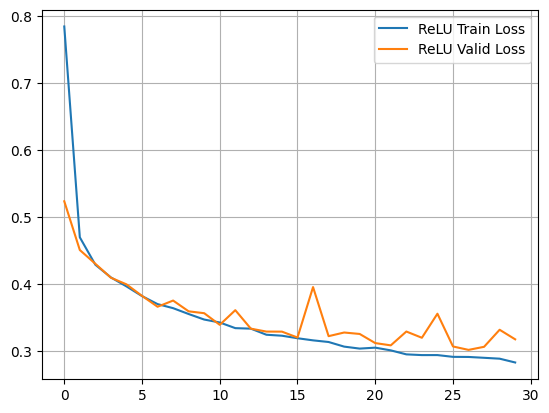

In [438]:
plt.plot(train_losses_relu, label = "ReLU Train Loss")
plt.plot(valid_losses_relu, label = "ReLU Valid Loss")
plt.legend()
plt.grid()
plt.show()

**TODO**: Let's now create a new class `MLP_Sigmoid` to create similar models but with Sigmoid activation instead of ReLU. Complete the following class definition by adding the Sigmoid activation function for the 2 hidden layers. 

In [445]:
class MLP_Sigmoid(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_outputs):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Linear(n_inputs, n_hidden1),
          nn.Sigmoid(),
          nn.Linear(n_hidden1, n_hidden2),
          nn.Sigmoid(),
          nn.Linear(n_hidden2, n_hidden3),
          nn.Sigmoid(),
          nn.Linear(n_hidden3, n_outputs)
          )
    def forward(self, X):
        return self.mlp(X)

**TODO**: 
- Train a model instanciated from the `MLP_Sigmoid` class, using the same other settings (learning rate; optimiser, loss and number of epochs) than previously.
- Plot the training and validation losses for the model using ReLU and the model using Sigmoid on the same graph.

In [ ]:
# TODO

In [447]:
# Solution
model = MLP_Sigmoid(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 30

In [449]:
train_losses_sig, valid_losses_sig = train(model, optimizer, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 1.3770, Valid Loss: 1.3788
Epoch 2/30, Training Loss: 1.3440, Valid Loss: 1.3318
Epoch 3/30, Training Loss: 1.3355, Valid Loss: 1.3228
Epoch 4/30, Training Loss: 1.3205, Valid Loss: 1.3195
Epoch 5/30, Training Loss: 1.2939, Valid Loss: 1.2658
Epoch 6/30, Training Loss: 1.2255, Valid Loss: 1.1549
Epoch 7/30, Training Loss: 1.0404, Valid Loss: 0.8864
Epoch 8/30, Training Loss: 0.7415, Valid Loss: 0.6646
Epoch 9/30, Training Loss: 0.6200, Valid Loss: 0.6285
Epoch 10/30, Training Loss: 0.5929, Valid Loss: 0.6460
Epoch 11/30, Training Loss: 0.5797, Valid Loss: 0.6001
Epoch 12/30, Training Loss: 0.5658, Valid Loss: 0.5805
Epoch 13/30, Training Loss: 0.5538, Valid Loss: 0.5681
Epoch 14/30, Training Loss: 0.5459, Valid Loss: 0.5607
Epoch 15/30, Training Loss: 0.5364, Valid Loss: 0.5614
Epoch 16/30, Training Loss: 0.5276, Valid Loss: 0.5362
Epoch 17/30, Training Loss: 0.5205, Valid Loss: 0.5286
Epoch 18/30, Training Loss: 0.5141, Valid Loss: 0.5395
Epoch 19/30, Traini

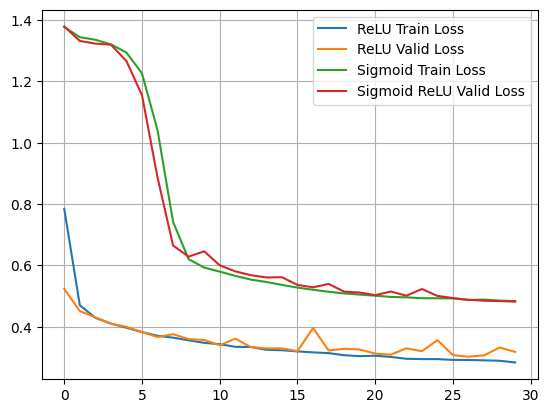

In [451]:
plt.plot(train_losses_relu, label = "ReLU Train Loss")
plt.plot(valid_losses_relu, label = "ReLU Valid Loss")
plt.plot(train_losses_sig, label = "Sigmoid Train Loss")
plt.plot(valid_losses_sig, label = "Sigmoid ReLU Valid Loss")
plt.legend()
plt.grid()
plt.show()

**TODO**: Have a look at the list of activation functions available in PyTorch and try out another one (e.g., Leaky ReLU). 

#### Output activation functions

The output activation function depends on the problem you are trying to solve:
- Regression: Linear activation with MSE, RMSE or MAE loss.
- Binary/Multilabel classification: Sigmoid with Binary Cross Entropy Loss.
- Multi-class classification: Softmax with Cross Entropy Loss.

**Important**: 
When doing binary/multilabel classification, either:
- Apply a `nn.Sigmoid()` activation function to your output layer and use `nn.BCELoss` as loss function, OR
- Do not apply `nn.Sigmoid()` activation function to your output layer and use `nn.BCEWithLogitsLoss` as loss function (applies sigmoid before BCE loss).
  In that case, you also will need to apply sigmoid to the output of the model at inference timle (after training).

When doing multi-class classification: 
- Do not apply `nn.Softmax()` activation function to your output as it is already applied in `nn.CrossEntropyLoss`.
- Apply the softmax function at inference time (after training). 


In [390]:
# MULTILABEL CLASSIFICATION 1 (also works for Binary classification)
# Either Sigmoid + BCELoss
class MultiLabelClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_classes):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Linear(n_inputs, n_hidden1),
          nn.ReLU(),
          nn.Linear(n_hidden1, n_hidden2),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_hidden3),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_classes)
          nn.Sigmoid()
      )
    def forward(self, X):
        return self.mlp(X)

model = MultiLabelClassifier(n_inputs=10, n_hidden1=50, n_hidden2=40, n_classes=5)
criterion = nn.BCELoss()  # Do not Automatically applies sigmoid
# ...

In [392]:
# MULTILABEL CLASSIFICATION 2 (also works for Binary classification)
# Or No Sigmoid + BCEWithLogitsLoss

class MultiLabelClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_classes):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Linear(n_inputs, n_hidden1),
          nn.ReLU(),
          nn.Linear(n_hidden1, n_hidden2),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_hidden3),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_classes)
          # No nn.Sigmoid here
      )
    def forward(self, X):
        return self.mlp(X)

model = MultiLabelClassifier(n_inputs=10, n_hidden1=50, n_hidden2=40, n_classes=5)
criterion = nn.BCEWithLogitsLoss()  # Automatically applies sigmoid
# ...

# At inference time
new_input = ... # Some new input
prediction = torch.sigmoid(model(new_input))

In [ ]:
# MULTI-CLASS CLASSIFICATION 

class MultiClassClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_classes):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Linear(n_inputs, n_hidden1),
          nn.ReLU(),
          nn.Linear(n_hidden1, n_hidden2),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_hidden3),
          nn.ReLU(),
          nn.Linear(n_hidden2, n_classes)
          # No nn.Softmax here
      )
    def forward(self, X):
        return self.mlp(X)

model = MultiLabelClassifier(n_inputs=10, n_hidden1=50, n_hidden2=40, n_classes=5)
criterion = nn.CrossEntropyLoss()  # Automatically applies softmax
# ...

# At inference time
new_input = ... # Some new input
prediction = torch.softmax(model(new_input))

## 2. Weights initialisation

The way the weights are initialised plays an important role to allow the signal to "flow" properly during the forward pass and the backpropagation of the gradients. I.e., we want to avoid values of activations and gradients to become too large or too small. This can be achieved by controling the variance or the bonds of the distribution from which the weights' values are drawn from. This helps to maintain a similar variance of ativations across the different layers and mitigate vanishing or exploding gradients.

There are two main initialisations used for the weights: 
- Xavier/Glorot initialisation for linear, tanh, sigmoid and softmax activation functions.
- Kaiming/He initialisation for ReLU and its variants (mitigate Dying ReLU problem).

Weights's values can be drawn from a normal or uniform distribution with variance/bounds calculated based on the number of neurons in the previous and next layer for Xavier/Glorot, or only based on the previous layer for Kaiming/He. 

Usually, drawing weigths' values from a uniform distribution is prefered for smaller networks, while drawing them from a normal distribution is prefered from deeper networks. 

The `nn.init` module contains several types of initialisation methods, including Xavier/Glorot and Kaiming/He uniform and normal. 

The following functions takes a module (i.e., a model) as input and apply Kaiming/He uniform or normal initialisation to the weigths. The biases are initialised to 0. It is acceptatble as the biases are not contributing to the symmetry problem as weigths do. Their primary role is to provide an adjustable threshold for neuron activation, so they can start from 0. 

In [357]:
def use_he_uniform_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [359]:
def use_he_normal_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_normal_(module.weight)
        nn.init.zeros_(module.bias)

**TODO**: Create similar functions for Xavier/Glorot initialisation.

In [363]:
# TODO

In [ ]:
# Solution
def use_xavier_uniform_init(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight)
        nn.init.zeros_(module.bias)

In [ ]:
def use_xavier_normal_init(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_normal_(module.weight)
        nn.init.zeros_(module.bias)

You can then use them after instantiating a model:

In [453]:
model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
model.apply(use_he_uniform_init)

MLP_ReLU(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8, out_features=200, bias=True)
    (2): ReLU()
    (3): Linear(in_features=200, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=50, bias=True)
    (6): ReLU()
    (7): Linear(in_features=50, out_features=1, bias=True)
  )
)

## 3. Regularisation 

#### 3.1. Dropout

Let's add some dropout in the input and hidden layers. 

In [457]:
class MLP_Dropout(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_outputs):
      super().__init__()
      self.mlp = nn.Sequential(
            nn.Dropout(p=0.2), nn.Linear(n_inputs, n_hidden1),
            nn.ReLU(),
            nn.Dropout(p=0.2), nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Dropout(p=0.2), nn.Linear(n_hidden2, n_hidden3),
            nn.ReLU(),
            nn.Dropout(p=0.2), nn.Linear(n_hidden3, n_outputs)
            )
    def forward(self, X):
        return self.mlp(X)

*Remark*: As dropout is behaving differently between training and evaluation, it is crutial to include the `model.train()` and `model.eval()` instructions in your training loop, to switch the model in training and evalaution mode, as we have already done.

In [459]:
model = MLP_Dropout(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3=50, n_outputs=1).to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 30

In [461]:
train_losses_drop, valid_losses_drop = train(model, optimizer, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 1.0335, Valid Loss: 0.6459
Epoch 2/30, Training Loss: 0.8048, Valid Loss: 0.6257
Epoch 3/30, Training Loss: 0.7878, Valid Loss: 0.6303
Epoch 4/30, Training Loss: 0.7805, Valid Loss: 0.6026
Epoch 5/30, Training Loss: 0.7546, Valid Loss: 0.5831
Epoch 6/30, Training Loss: 0.7633, Valid Loss: 0.5992
Epoch 7/30, Training Loss: 0.7326, Valid Loss: 0.5603
Epoch 8/30, Training Loss: 0.7491, Valid Loss: 0.5648
Epoch 9/30, Training Loss: 0.7262, Valid Loss: 0.5561
Epoch 10/30, Training Loss: 0.7153, Valid Loss: 0.5616
Epoch 11/30, Training Loss: 0.7200, Valid Loss: 0.5306
Epoch 12/30, Training Loss: 0.7206, Valid Loss: 0.5361
Epoch 13/30, Training Loss: 0.7022, Valid Loss: 0.5348
Epoch 14/30, Training Loss: 0.6942, Valid Loss: 0.5150
Epoch 15/30, Training Loss: 0.6699, Valid Loss: 0.5386
Epoch 16/30, Training Loss: 0.6715, Valid Loss: 0.5266
Epoch 17/30, Training Loss: 0.6586, Valid Loss: 0.5041
Epoch 18/30, Training Loss: 0.6509, Valid Loss: 0.5090
Epoch 19/30, Traini

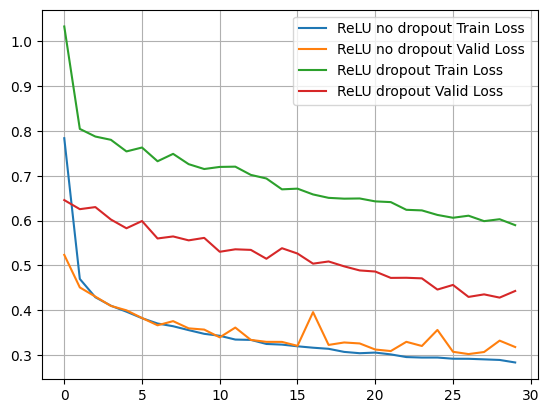

In [463]:
plt.plot(train_losses_relu, label = "ReLU no dropout Train Loss")
plt.plot(valid_losses_relu, label = "ReLU no dropout Valid Loss")
plt.plot(train_losses_drop, label = "ReLU dropout Train Loss")
plt.plot(valid_losses_drop, label = "ReLU dropout Valid Loss")
plt.legend()
plt.grid()
plt.show()

**TODO**: Looking at the train and validation losses with dropout activated can be misleading. What do you observe? Does this makes sense given we are using dropout?

The effect of dropout as regularisation is not so visible as our network and task are not too complex, with not much overfitting. However, using dropout can lead to higher validation performance (i.e., lower validation loss) with deeper networks and more complex problems prone to overfitting. 

#### 3.2. L1 and L2 regularisation

To implement L1 and L2 regularisation, you need to modify the loss in the training function.

In [465]:
def train_reg(model, optimizer, loss_fn, train_loader, valid_loader, n_epochs, reg_type = "l1", alpha_reg = 1e-4):
    train_losses = []
    valid_losses = []
    params_to_regularize = [param for name, param in model.named_parameters() if not "bias" in name and not "bn" in name]
    
    for epoch in range(n_epochs):
        #Training
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)

            if reg_type == "l1":
                # l1 Regularisation
                main_loss = loss_fn(y_train_pred, y_train_batch)
                l1_loss = sum(param.abs().sum() for param in params_to_regularize)
                train_loss = main_loss + alpha_reg * l1_loss
            else:
                # l2 Regularisation
                main_loss = loss_fn(y_train_pred, y_train_batch)
                l2_loss = sum(param.pow(2.0).sum() for param in params_to_regularize)
                train_loss = main_loss + alpha_reg * l2_loss
            
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)

        # Validation
        model.eval()
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")

    return (train_losses, valid_losses)

In [467]:
model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 30

In [469]:
train_losses_l2, valid_losses_l2 = train_reg(model, optimizer, mse, train_loader, valid_loader, n_epochs, "l2", 1e-4)

Epoch 1/30, Training Loss: 0.8318, Valid Loss: 0.5111
Epoch 2/30, Training Loss: 0.4793, Valid Loss: 0.4413
Epoch 3/30, Training Loss: 0.4377, Valid Loss: 0.4157
Epoch 4/30, Training Loss: 0.4171, Valid Loss: 0.4018
Epoch 5/30, Training Loss: 0.4068, Valid Loss: 0.3938
Epoch 6/30, Training Loss: 0.3930, Valid Loss: 0.3667
Epoch 7/30, Training Loss: 0.3857, Valid Loss: 0.3630
Epoch 8/30, Training Loss: 0.3736, Valid Loss: 0.3622
Epoch 9/30, Training Loss: 0.3658, Valid Loss: 0.3781
Epoch 10/30, Training Loss: 0.3585, Valid Loss: 0.3569
Epoch 11/30, Training Loss: 0.3527, Valid Loss: 0.3489
Epoch 12/30, Training Loss: 0.3481, Valid Loss: 0.3474
Epoch 13/30, Training Loss: 0.3438, Valid Loss: 0.3396
Epoch 14/30, Training Loss: 0.3376, Valid Loss: 0.3276
Epoch 15/30, Training Loss: 0.3372, Valid Loss: 0.3447
Epoch 16/30, Training Loss: 0.3332, Valid Loss: 0.3418
Epoch 17/30, Training Loss: 0.3291, Valid Loss: 0.3262
Epoch 18/30, Training Loss: 0.3256, Valid Loss: 0.3250
Epoch 19/30, Traini

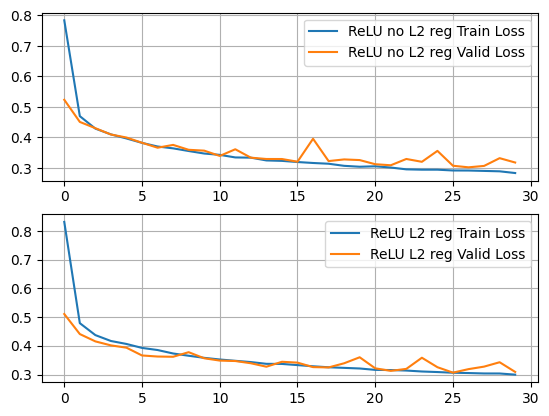

In [471]:
plt.subplot(2, 1, 1)
plt.plot(train_losses_relu, label = "ReLU no L2 reg Train Loss")
plt.plot(valid_losses_relu, label = "ReLU no L2 reg Valid Loss")
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(train_losses_l2, label = "ReLU L2 reg Train Loss")
plt.plot(valid_losses_l2, label = "ReLU L2 reg Valid Loss")
plt.legend()
plt.grid()
plt.show()

#### 3.3. Early stopping

Simple implementation in training loop

+ Link to class implementation and ignite torch examples

Below is a simple implementation of early stopping i nthe training loop. It simply stops the training if the validation loss for an epoch is higher than in the previous epoch, and reverts the model to the model from the previous epoch. 

In [553]:
def train_with_early_stopping(model, optimizer, loss_fn, train_loader, valid_loader, n_epochs):
    train_losses = []
    valid_losses = []

    for epoch in range(n_epochs):
        #Training
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)

        # Validation
        model.eval()
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        
        # Early stopping
        if epoch == 0:
            previous_loss = mean_epoch_valid_loss
            previous_model = deepcopy(model)
            valid_losses.append(mean_epoch_valid_loss)
        else: 
            if mean_epoch_valid_loss > previous_loss:
                model = deepcopy(previous_model)
                print(f"Training stopped after epoch {epoch + 1}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}.")
                break
            else: 
                previous_loss = mean_epoch_valid_loss
                previous_model = deepcopy(model)
                valid_losses.append(mean_epoch_valid_loss)
            
        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")

    return (train_losses, valid_losses)

In [557]:
model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 30

In [559]:
train_losses_early_stop, valid_losses_early_stop = train_with_early_stopping(model, optimizer, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 0.7935, Valid Loss: 0.5085
Epoch 2/30, Training Loss: 0.4724, Valid Loss: 0.4613
Epoch 3/30, Training Loss: 0.4368, Valid Loss: 0.4227
Epoch 4/30, Training Loss: 0.4118, Valid Loss: 0.4225
Epoch 5/30, Training Loss: 0.3955, Valid Loss: 0.3921
Training stopped after epoch 6, Training Loss: 0.3885, Valid Loss: 0.3945.


This basic version of early stopping might be to rigid and you might want to add a `patience` parameter to control the number of epochs without progress in validation loss seen before stopping the training. 

You can find a more advanced implementation of early stopping [here](https://www.geeksforgeeks.org/how-to-handle-overfitting-in-pytorch-models-using-early-stopping/).
The PyTorch Ignite and Lightning libraries also offer a more ready to use `EarlyStopping` class, but they are based on a different high-level API specific to these libraries. Do not hesitate to explore these, with ChatGPT as an assitant!

## Coding time 2

- Hyperparameter tuning with Optuna
- Learning rate schedule
- Batch norm
- Faster optimisers

### 1. Hyperparameter tuning with Optuna

Several dedicated libraries can be used for hyperparamter tuning with PyTorch models. For example:
- [Optuna](https://optuna.org/)
- [Ray Tune](https://docs.ray.io/)
- [Hyperopt](https://hyperopt.github.io/hyperopt/)

We will see an example with using Optuna.
  

We first need to create a function that takes a `Trial` object and use it to have Optuna suggest hyperparameter values to try, train and evaluate a model with the selected hyperparameter values, and return the corresponding validation performance using a given evaluation metric. 

We start by trying to optimise the learning rate value (float) and the number of neurons in each hidden layer (int). We use the MSE loss as evaluation metric (for classification, we could use accuracy or another target metric).

Note: it is also possible to tune categorical hyperparameters with Optuna, using the `suggest_categorical()` method. 

In [705]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True) # Suggest a float value in the chosen range
    n_hidden1 = trial.suggest_int("n_hidden1", 100, 300) # Suggest an int value in the chosen range
    n_hidden2 = trial.suggest_int("n_hidden2", 50, 200) # Suggest an int value in the chosen range
    n_hidden3 = trial.suggest_int("n_hidden3", 20, 100) # Suggest an int value in the chosen range
    model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_hidden3=n_hidden3, n_outputs=1).to(device)
    mse = nn.MSELoss()
    n_epochs = 30
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    _ , valid_losses = train(model, optimizer, mse, train_loader, valid_loader, n_epochs)
    return valid_losses[-1]

Then, we need to create `Sampler` object specifying the algorithm we want to use for the optimisation. Some algorithms might select purely random values at each trial, some will use past information to guide the search. You can have a look at the different Optuna sampler algorithm options in the [documentation](https://optuna.readthedocs.io/en/stable/reference/samplers/index.html).

Then, we need to create a `Study` object and pass the sampler as an argument, as well as the `direction` of the optimisation. In our case, we want to minimise the MSE used as evalaution metric. 

Finally, we can start the hyperparameter tuning by calling the `optimize` method and passing the objective function and number of trial as arguments. The number of trials correspond to the number of hyperparameter combinations the algorithm will try. The highest this number is, the more chance you have to find good hyperparameter values, but the longer it will take.

To pass the training and validations sets loader to the objective function, we can use the `functools.partial()` function which allows to provide default values for the objective fucntion arguments. 

In [707]:
sampler = optuna.samplers.TPESampler() # Use the Tree-structured Parzen Estimator algorithm for the optimisation
study = optuna.create_study(direction="minimize", sampler=sampler)
objective_with_data = partial(objective, train_loader=train_loader, valid_loader=valid_loader)
study.optimize(objective_with_data, n_trials=5)

[I 2025-03-20 20:48:24,290] A new study created in memory with name: no-name-1cdd60f6-c37c-4ea7-9ee6-0e3636d46e4c


Epoch 1/30, Training Loss: 4.6843, Valid Loss: 4.5985
Epoch 2/30, Training Loss: 4.5190, Valid Loss: 4.4348
Epoch 3/30, Training Loss: 4.3558, Valid Loss: 4.2725
Epoch 4/30, Training Loss: 4.1938, Valid Loss: 4.1111
Epoch 5/30, Training Loss: 4.0327, Valid Loss: 3.9501
Epoch 6/30, Training Loss: 3.8719, Valid Loss: 3.7891
Epoch 7/30, Training Loss: 3.7114, Valid Loss: 3.6279
Epoch 8/30, Training Loss: 3.5508, Valid Loss: 3.4662
Epoch 9/30, Training Loss: 3.3903, Valid Loss: 3.3044
Epoch 10/30, Training Loss: 3.2302, Valid Loss: 3.1429
Epoch 11/30, Training Loss: 3.0710, Valid Loss: 2.9821
Epoch 12/30, Training Loss: 2.9136, Valid Loss: 2.8229
Epoch 13/30, Training Loss: 2.7587, Valid Loss: 2.6662
Epoch 14/30, Training Loss: 2.6074, Valid Loss: 2.5131
Epoch 15/30, Training Loss: 2.4607, Valid Loss: 2.3644
Epoch 16/30, Training Loss: 2.3198, Valid Loss: 2.2218
Epoch 17/30, Training Loss: 2.1857, Valid Loss: 2.0859
Epoch 18/30, Training Loss: 2.0595, Valid Loss: 1.9578
Epoch 19/30, Traini

[I 2025-03-20 20:48:37,955] Trial 0 finished with value: 1.1103585741316626 and parameters: {'learning_rate': 1.3606075028604626e-05, 'n_hidden1': 258, 'n_hidden2': 87, 'n_hidden3': 73}. Best is trial 0 with value: 1.1103585741316626.


Epoch 30/30, Training Loss: 1.2210, Valid Loss: 1.1104
Epoch 1/30, Training Loss: 0.7829, Valid Loss: 0.5148
Epoch 2/30, Training Loss: 0.4760, Valid Loss: 0.4570
Epoch 3/30, Training Loss: 0.4462, Valid Loss: 0.4312
Epoch 4/30, Training Loss: 0.4260, Valid Loss: 0.4161
Epoch 5/30, Training Loss: 0.4067, Valid Loss: 0.4041
Epoch 6/30, Training Loss: 0.3936, Valid Loss: 0.3818
Epoch 7/30, Training Loss: 0.3793, Valid Loss: 0.3774
Epoch 8/30, Training Loss: 0.3725, Valid Loss: 0.4284
Epoch 9/30, Training Loss: 0.3663, Valid Loss: 0.3690
Epoch 10/30, Training Loss: 0.3552, Valid Loss: 0.4169
Epoch 11/30, Training Loss: 0.3513, Valid Loss: 0.3440
Epoch 12/30, Training Loss: 0.3466, Valid Loss: 0.3428
Epoch 13/30, Training Loss: 0.3375, Valid Loss: 0.3504
Epoch 14/30, Training Loss: 0.3359, Valid Loss: 0.3451
Epoch 15/30, Training Loss: 0.3323, Valid Loss: 0.3345
Epoch 16/30, Training Loss: 0.3266, Valid Loss: 0.3361
Epoch 17/30, Training Loss: 0.3250, Valid Loss: 0.3336
Epoch 18/30, Traini

[I 2025-03-20 20:48:51,807] Trial 1 finished with value: 0.3068707761491916 and parameters: {'learning_rate': 0.008379161097857319, 'n_hidden1': 248, 'n_hidden2': 100, 'n_hidden3': 76}. Best is trial 1 with value: 0.3068707761491916.


...

Epoch 30/30, Training Loss: 0.5299, Valid Loss: 0.5460
Epoch 1/30, Training Loss: 0.6179, Valid Loss: 0.4573
Epoch 2/30, Training Loss: 0.4599, Valid Loss: 0.5299
Epoch 3/30, Training Loss: 0.4133, Valid Loss: 0.3705
Epoch 4/30, Training Loss: 0.3864, Valid Loss: 0.3522
Epoch 5/30, Training Loss: 0.3680, Valid Loss: 0.6062
Epoch 6/30, Training Loss: 0.3513, Valid Loss: 0.3602
Epoch 7/30, Training Loss: 0.3412, Valid Loss: 0.3791
Epoch 8/30, Training Loss: 0.3338, Valid Loss: 0.3140
Epoch 9/30, Training Loss: 0.3252, Valid Loss: 0.3507
Epoch 10/30, Training Loss: 0.3171, Valid Loss: 0.3160
Epoch 11/30, Training Loss: 0.3128, Valid Loss: 0.3135
Epoch 12/30, Training Loss: 0.3071, Valid Loss: 0.3715
Epoch 13/30, Training Loss: 0.3036, Valid Loss: 0.3092
Epoch 14/30, Training Loss: 0.3347, Valid Loss: 0.4408
Epoch 15/30, Training Loss: nan, Valid Loss: nan
Epoch 16/30, Training Loss: nan, Valid Loss: nan
Epoch 17/30, Training Loss: nan, Valid Loss: nan
Epoch 18/30, Training Loss: nan, Vali

[W 2025-03-20 20:49:19,187] Trial 3 failed with parameters: {'learning_rate': 0.07686517647850569, 'n_hidden1': 283, 'n_hidden2': 137, 'n_hidden3': 20} because of the following error: The value nan is not acceptable.
[W 2025-03-20 20:49:19,187] Trial 3 failed with value nan.


Epoch 30/30, Training Loss: nan, Valid Loss: nan
Epoch 1/30, Training Loss: 1.1229, Valid Loss: 0.5669
Epoch 2/30, Training Loss: 0.5004, Valid Loss: 0.4679
Epoch 3/30, Training Loss: 0.4539, Valid Loss: 0.4367
Epoch 4/30, Training Loss: 0.4255, Valid Loss: 0.4107
Epoch 5/30, Training Loss: 0.4058, Valid Loss: 0.4114
Epoch 6/30, Training Loss: 0.4080, Valid Loss: 0.3934
Epoch 7/30, Training Loss: 0.3852, Valid Loss: 0.3826
Epoch 8/30, Training Loss: 0.3756, Valid Loss: 0.3758
Epoch 9/30, Training Loss: 0.3649, Valid Loss: 0.4008
Epoch 10/30, Training Loss: 0.3606, Valid Loss: 0.3680
Epoch 11/30, Training Loss: 0.3538, Valid Loss: 0.3556
Epoch 12/30, Training Loss: 0.3468, Valid Loss: 0.4196
Epoch 13/30, Training Loss: 0.3427, Valid Loss: 0.3542
Epoch 14/30, Training Loss: 0.3375, Valid Loss: 0.3558
Epoch 15/30, Training Loss: 0.3376, Valid Loss: 0.3425
Epoch 16/30, Training Loss: 0.3292, Valid Loss: 0.3342
Epoch 17/30, Training Loss: 0.3276, Valid Loss: 0.3418
Epoch 18/30, Training Los

[I 2025-03-20 20:49:33,086] Trial 4 finished with value: 0.30640801637209664 and parameters: {'learning_rate': 0.008453241715010482, 'n_hidden1': 150, 'n_hidden2': 107, 'n_hidden3': 40}. Best is trial 4 with value: 0.30640801637209664.


Epoch 30/30, Training Loss: 0.2999, Valid Loss: 0.3064


The best hyperparameter values are found in `study.best_params` and the corresponding best evaluation metric value in `study.best_value`.

In [709]:
study.best_params

{'learning_rate': 0.008453241715010482,
 'n_hidden1': 150,
 'n_hidden2': 107,
 'n_hidden3': 40}

In [711]:
study.best_value

0.30640801637209664

**TODO**: Try to let it run for longer and see if it can find significantly better values!

To speed up the process, you can use a `Pruner` to stop trials that are leading nowehere (i.e., whose performance is below previously seen trials). For example, the `MedianPruner` will stop a trial if its performance is below the median of previous trials. The pruner needs to warmup first over a couple of trials set with the `n_startup_trials` parameter (5 by default). After that, it will monitor the performance every few epoch (set with the `interval_steps` parameter), after a few first warmup epoch (set with the `n_warmup_steps` parameter). For each of the controlled epochs, it verifies if the perfomance is better than the median perfomance at the same epoch for previous completed trials. 


In [719]:
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0, interval_steps=1)
study = optuna.create_study(direction="minimize", sampler=sampler, pruner=pruner)

[I 2025-03-20 21:01:33,293] A new study created in memory with name: no-name-ea6dcb10-89c1-4feb-89d0-d8b99f45825f


To use the pruner, you need to pass information about the validation performance after each epoch of training during a trial. In our case, we need to modify the train function.

In [730]:
def train_for_pruner(model, optimizer, loss_fn, train_loader, valid_loader, n_epochs):
    train_losses = []
    valid_losses = []

    for epoch in range(n_epochs):
        #Training
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)

        # Validation
        model.eval()
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)

        # Pass information to Optuna about the validation performance for the last epoch
        trial.report(valid_losses[-1], epoch)
        # Raise an exception to stop the training if Optuna's pruner decides to prune the current trial
        if trial.should_prune():
            raise optuna.TrialPruned()

        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")

    return (train_losses, valid_losses)

In [732]:
def objective(trial, train_loader, valid_loader):
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True) # Suggest a float value in the chosen range
    n_hidden1 = trial.suggest_int("n_hidden1", 100, 300) # Suggest an int value in the chosen range
    n_hidden2 = trial.suggest_int("n_hidden2", 50, 200) # Suggest an int value in the chosen range
    n_hidden3 = trial.suggest_int("n_hidden3", 20, 100) # Suggest an int value in the chosen range
    model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=n_hidden1, n_hidden2=n_hidden2, n_hidden3=n_hidden3, n_outputs=1).to(device)
    mse = nn.MSELoss()
    n_epochs = 30
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    _ , valid_losses = train_for_pruner(model, optimizer, mse, train_loader, valid_loader, n_epochs) # NEW: Changed the train_for_pruner to use for pruning
    return valid_losses[-1]

In [728]:
study.optimize(objective_with_data, n_trials=10) # Runs 5 trials without pruning and then activates the pruning until reaching 10 trials

Epoch 1/30, Training Loss: 0.7770, Valid Loss: 0.5257
Epoch 2/30, Training Loss: 0.4750, Valid Loss: 0.4689
Epoch 3/30, Training Loss: 0.4284, Valid Loss: 0.4151
Epoch 4/30, Training Loss: 0.4078, Valid Loss: 0.4006
Epoch 5/30, Training Loss: 0.3966, Valid Loss: 0.3832
Epoch 6/30, Training Loss: 0.3802, Valid Loss: 0.3821
Epoch 7/30, Training Loss: 0.3697, Valid Loss: 0.3684
Epoch 8/30, Training Loss: 0.3635, Valid Loss: 0.3592
Epoch 9/30, Training Loss: 0.3525, Valid Loss: 0.3587
Epoch 10/30, Training Loss: 0.3478, Valid Loss: 0.3479
Epoch 11/30, Training Loss: 0.3449, Valid Loss: 0.3471
Epoch 12/30, Training Loss: 0.3362, Valid Loss: 0.3440
Epoch 13/30, Training Loss: 0.3340, Valid Loss: 0.3339
Epoch 14/30, Training Loss: 0.3267, Valid Loss: 0.3326
Epoch 15/30, Training Loss: 0.3266, Valid Loss: 0.3828
Epoch 16/30, Training Loss: 0.3226, Valid Loss: 0.3212
Epoch 17/30, Training Loss: 0.3196, Valid Loss: 0.3267
Epoch 18/30, Training Loss: 0.3116, Valid Loss: 0.3267
Epoch 19/30, Traini

[I 2025-03-20 21:08:02,525] Trial 0 finished with value: 0.3157700066880662 and parameters: {'learning_rate': 0.00887369645340016, 'n_hidden1': 286, 'n_hidden2': 100, 'n_hidden3': 26}. Best is trial 0 with value: 0.3157700066880662.


Epoch 30/30, Training Loss: 0.2884, Valid Loss: 0.3158
Epoch 1/30, Training Loss: 5.2179, Valid Loss: 4.4989
Epoch 2/30, Training Loss: 3.7823, Valid Loss: 3.0304
Epoch 3/30, Training Loss: 2.4465, Valid Loss: 1.8179
Epoch 4/30, Training Loss: 1.6428, Valid Loss: 1.2610
Epoch 5/30, Training Loss: 1.3045, Valid Loss: 1.0421
Epoch 6/30, Training Loss: 1.1248, Valid Loss: 0.9399
Epoch 7/30, Training Loss: 0.9976, Valid Loss: 0.8648
Epoch 8/30, Training Loss: 0.9016, Valid Loss: 0.8073
Epoch 9/30, Training Loss: 0.8300, Valid Loss: 0.7657
Epoch 10/30, Training Loss: 0.7757, Valid Loss: 0.7344
Epoch 11/30, Training Loss: 0.7352, Valid Loss: 0.7103
Epoch 12/30, Training Loss: 0.7054, Valid Loss: 0.6914
Epoch 13/30, Training Loss: 0.6834, Valid Loss: 0.6772
Epoch 14/30, Training Loss: 0.6664, Valid Loss: 0.6660
Epoch 15/30, Training Loss: 0.6531, Valid Loss: 0.6567
Epoch 16/30, Training Loss: 0.6424, Valid Loss: 0.6488
Epoch 17/30, Training Loss: 0.6334, Valid Loss: 0.6418
Epoch 18/30, Traini

[I 2025-03-20 21:08:15,739] Trial 1 finished with value: 0.5766630653263063 and parameters: {'learning_rate': 0.00012283164628504157, 'n_hidden1': 232, 'n_hidden2': 110, 'n_hidden3': 35}. Best is trial 0 with value: 0.3157700066880662.


Epoch 30/30, Training Loss: 0.5652, Valid Loss: 0.5767
Epoch 1/30, Training Loss: 0.8441, Valid Loss: 0.5462
Epoch 2/30, Training Loss: 0.4843, Valid Loss: 0.4660
Epoch 3/30, Training Loss: 0.4360, Valid Loss: 0.4264
Epoch 4/30, Training Loss: 0.4134, Valid Loss: 0.4080
Epoch 5/30, Training Loss: 0.3983, Valid Loss: 0.4617
Epoch 6/30, Training Loss: 0.3843, Valid Loss: 0.3765
Epoch 7/30, Training Loss: 0.3752, Valid Loss: 0.4131
Epoch 8/30, Training Loss: 0.3664, Valid Loss: 0.3607
Epoch 9/30, Training Loss: 0.3600, Valid Loss: 0.3637
Epoch 10/30, Training Loss: 0.3507, Valid Loss: 0.3533
Epoch 11/30, Training Loss: 0.3448, Valid Loss: 0.3514
Epoch 12/30, Training Loss: 0.3409, Valid Loss: 0.3415
Epoch 13/30, Training Loss: 0.3344, Valid Loss: 0.3347
Epoch 14/30, Training Loss: 0.3318, Valid Loss: 0.3368
Epoch 15/30, Training Loss: 0.3262, Valid Loss: 0.3431
Epoch 16/30, Training Loss: 0.3227, Valid Loss: 0.3258
Epoch 17/30, Training Loss: 0.3192, Valid Loss: 0.3191
Epoch 18/30, Traini

...

Epoch 30/30, Training Loss: 0.2942, Valid Loss: 0.3046
Epoch 1/30, Training Loss: 0.8533, Valid Loss: 0.5032
Epoch 2/30, Training Loss: 0.5198, Valid Loss: 0.4453
Epoch 3/30, Training Loss: 0.4340, Valid Loss: 0.5036
Epoch 4/30, Training Loss: 0.4371, Valid Loss: 0.4088
Epoch 5/30, Training Loss: 0.3978, Valid Loss: 0.3787
Epoch 6/30, Training Loss: 0.3818, Valid Loss: 0.3600
Epoch 7/30, Training Loss: 0.3730, Valid Loss: 0.3647
Epoch 8/30, Training Loss: 0.3636, Valid Loss: 0.3547
Epoch 9/30, Training Loss: 0.3543, Valid Loss: 0.4362
Epoch 10/30, Training Loss: 0.3435, Valid Loss: 0.3295
Epoch 11/30, Training Loss: 0.3380, Valid Loss: 0.3201
Epoch 12/30, Training Loss: 0.3318, Valid Loss: 0.3307
Epoch 13/30, Training Loss: 0.3311, Valid Loss: 0.3181
Epoch 14/30, Training Loss: 0.3212, Valid Loss: 0.3387
Epoch 15/30, Training Loss: 0.3171, Valid Loss: 0.3231
Epoch 16/30, Training Loss: 0.3127, Valid Loss: 0.3150
Epoch 17/30, Training Loss: 0.3102, Valid Loss: 0.3343
Epoch 18/30, Traini

[I 2025-03-20 21:09:59,293] Trial 8 finished with value: 0.30847787244837416 and parameters: {'learning_rate': 0.0260671407453298, 'n_hidden1': 186, 'n_hidden2': 73, 'n_hidden3': 34}. Best is trial 6 with value: 0.29256733200808827.


Epoch 30/30, Training Loss: 0.2777, Valid Loss: 0.3085
Epoch 1/30, Training Loss: 0.6336, Valid Loss: 0.4625
Epoch 2/30, Training Loss: 0.4618, Valid Loss: 0.3919
Epoch 3/30, Training Loss: 0.4224, Valid Loss: 0.3888
Epoch 4/30, Training Loss: 0.3943, Valid Loss: 0.3482
Epoch 5/30, Training Loss: 0.3734, Valid Loss: 0.3443
Epoch 6/30, Training Loss: 0.3674, Valid Loss: 0.5387
Epoch 7/30, Training Loss: 0.3490, Valid Loss: 0.3251
Epoch 8/30, Training Loss: 0.3384, Valid Loss: 0.3298
Epoch 9/30, Training Loss: 0.3433, Valid Loss: 0.3249
Epoch 10/30, Training Loss: 0.3276, Valid Loss: 0.3371
Epoch 11/30, Training Loss: 0.3144, Valid Loss: 0.3399
Epoch 12/30, Training Loss: 0.3233, Valid Loss: 0.3367
Epoch 13/30, Training Loss: 0.3065, Valid Loss: 0.3713
Epoch 14/30, Training Loss: 0.3097, Valid Loss: 0.3279
Epoch 15/30, Training Loss: 0.3003, Valid Loss: 0.3688
Epoch 16/30, Training Loss: 0.2961, Valid Loss: 0.3721
Epoch 17/30, Training Loss: nan, Valid Loss: nan
Epoch 18/30, Training Los

[W 2025-03-20 21:10:15,840] Trial 9 failed with parameters: {'learning_rate': 0.09993505036459165, 'n_hidden1': 157, 'n_hidden2': 78, 'n_hidden3': 31} because of the following error: The value nan is not acceptable.
[W 2025-03-20 21:10:15,840] Trial 9 failed with value nan.


Epoch 30/30, Training Loss: nan, Valid Loss: nan


You can read more about Optuna range of pruners in the [documentation](https://optuna.readthedocs.io/en/stable/reference/pruners.html).

### 2. Learning rate schedule

The `torch.optim` module contains a sub-module called `lr_scheduler` which allows you to use several types of schedulers.

First, we need to modify the training loop to accept a scheduler as parameter, and update the scheduler (i.e., the learning rate) during the training, in a similar fashion we update the optimiser.

In [659]:
def train_with_scheduler(model, optimizer, scheduler, loss_fn, train_loader, valid_loader, n_epochs):
    train_losses = []
    valid_losses = []

    for epoch in range(n_epochs):
        #Training
        model.train()
        epoch_train_loss = 0.
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch, y_train_batch = X_train_batch.to(device), y_train_batch.to(device)
            y_train_pred = model(X_train_batch)
            train_loss = loss_fn(y_train_pred, y_train_batch)
            epoch_train_loss += train_loss.item()
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_epoch_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(mean_epoch_train_loss)

        # Scheduler update for every epoch (can be moved inside epoch loop for updates at every batch)
        before_lr = optimizer.param_groups[0]["lr"]
        scheduler.step() # Take a step of scheduler at the end of the epoch
        after_lr = optimizer.param_groups[0]["lr"]
        
        
        # Validation
        model.eval()
        epoch_valid_loss = 0.
        with torch.no_grad():
            for X_valid_batch, y_valid_batch in valid_loader:
                X_valid_batch, y_valid_batch = X_valid_batch.to(device), y_valid_batch.to(device)
                y_valid_pred = model(X_valid_batch)
                valid_loss = loss_fn(y_valid_pred, y_valid_batch)
                epoch_valid_loss += valid_loss.item()
        mean_epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        valid_losses.append(mean_epoch_valid_loss)
        
        print(f"Epoch {epoch + 1}/{n_epochs}, Training Loss: {mean_epoch_train_loss:.4f}, Valid Loss: {mean_epoch_valid_loss:.4f}")
        print(f"Epoch {epoch  + 1}: SGD lr {before_lr} -> {after_lr}")

    return (train_losses, valid_losses)

We then need to instantiate a scheduler before training and "link" it to the optimiser.

Below, we use a linear scheduler which will decay the learning rate linearly from the original leanring rate value to 50% of its original value over 20 epochs. After 20 epochs, the learning rate will remain constant at 50% of its original value. 

In [674]:
model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
n_epochs = 30
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=1.0, end_factor=0.5, total_iters=20)
#scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=2, T_mult=2, eta_min=0.001)
#scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(train_loader), epochs=n_epochs) # Need to move scheduler update in epoch loop
mse = nn.MSELoss()

In [676]:
train_losses_lr_sched, valid_losses_lr_sched = train_with_scheduler(model, optimizer, scheduler, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 0.7463, Valid Loss: 0.5105
Epoch 1: SGD lr 0.01 -> 0.00975
Epoch 2/30, Training Loss: 0.4692, Valid Loss: 0.4507
Epoch 2: SGD lr 0.00975 -> 0.0095
Epoch 3/30, Training Loss: 0.4365, Valid Loss: 0.4337
Epoch 3: SGD lr 0.0095 -> 0.00925
Epoch 4/30, Training Loss: 0.4168, Valid Loss: 0.4025
Epoch 4: SGD lr 0.00925 -> 0.009
Epoch 5/30, Training Loss: 0.3982, Valid Loss: 0.4166
Epoch 5: SGD lr 0.009 -> 0.008749999999999999
Epoch 6/30, Training Loss: 0.3857, Valid Loss: 0.3777
Epoch 6: SGD lr 0.008749999999999999 -> 0.008499999999999999
Epoch 7/30, Training Loss: 0.3750, Valid Loss: 0.4051
Epoch 7: SGD lr 0.008499999999999999 -> 0.008249999999999999
Epoch 8/30, Training Loss: 0.3687, Valid Loss: 0.3665
Epoch 8: SGD lr 0.008249999999999999 -> 0.007999999999999998
Epoch 9/30, Training Loss: 0.3617, Valid Loss: 0.3807
Epoch 9: SGD lr 0.007999999999999998 -> 0.007749999999999998
Epoch 10/30, Training Loss: 0.3534, Valid Loss: 0.3573
Epoch 10: SGD lr 0.00774999999999999

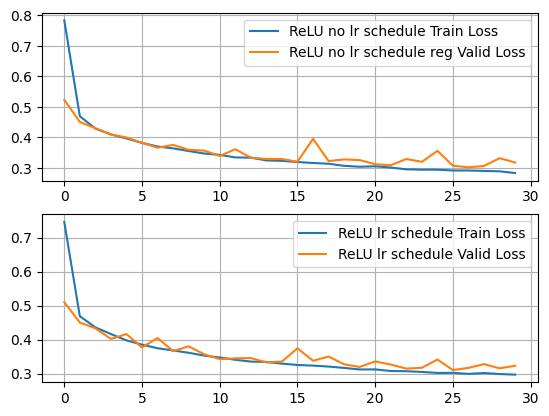

In [678]:
plt.subplot(2, 1, 1)
plt.plot(train_losses_relu, label = "ReLU no lr schedule Train Loss")
plt.plot(valid_losses_relu, label = "ReLU no lr schedule reg Valid Loss")
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(train_losses_lr_sched, label = "ReLU lr schedule Train Loss")
plt.plot(valid_losses_lr_sched, label = "ReLU lr schedule Valid Loss")
plt.legend()
plt.grid()
plt.show()

PyTorch provide a lot of different learning rate schedules you can use. Some examples are shown in [this Kaggle notebook](https://www.kaggle.com/code/isbhargav/guide-to-pytorch-learning-rate-scheduling). 

**TODO**: Try to use other learning rate schedules and see the impact on training. Some schedules alternate increasing and decreasing the learning rate to try to escape local optimum (e.g., `CosineAnnealingLR` or `OneCycleLR`).

### 3. Batch-normalisation

Let's include batch normalisation layers in our network. The authors of the method advocate to place them before the activation function of each layer, but this is a debated issues. In the case below, we placed them after the activation functions as it seems to work better. The choice seems to depend on your network architecture, therefore you can try both and see what works best fro you model.

In [487]:
class MLP_BN(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_hidden3, n_outputs):
      super().__init__()
      self.mlp = nn.Sequential(
          nn.Linear(n_inputs, n_hidden1),
          nn.ReLU(),
          nn.BatchNorm1d(n_hidden1),
          nn.Linear(n_hidden1, n_hidden2),
          nn.ReLU(),
          nn.BatchNorm1d(n_hidden2),
          nn.Linear(n_hidden2, n_hidden3),
          nn.ReLU(),
          nn.BatchNorm1d(n_hidden3),
          nn.Linear(n_hidden3, n_outputs)
          )
    def forward(self, X):
        return self.mlp(X)

*Remarks*: 
- As batch normalisation is behaving differently between training and evaluation, it is crutial to include the `model.train()` and `model.eval()` instructions in your training loop, to switch the model in training and evaluation mode, as we have already done.
- For models dealing with data in 2 or 3 dimensions (e.g., convolutional neural networks work with 2D images), you can use `nn.BatchNorm2d` or `nn.BatchNorm3d`.

In [505]:
model = MLP_BN(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()
n_epochs = 30

In [491]:
train_losses_bn, valid_losses_bn = train(model, optimizer, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 0.7459, Valid Loss: 0.4483
Epoch 2/30, Training Loss: 0.4486, Valid Loss: 0.3812
Epoch 3/30, Training Loss: 0.4165, Valid Loss: 0.3739
Epoch 4/30, Training Loss: 0.3976, Valid Loss: 0.3677
Epoch 5/30, Training Loss: 0.3864, Valid Loss: 0.3756
Epoch 6/30, Training Loss: 0.3827, Valid Loss: 0.3886
Epoch 7/30, Training Loss: 0.3692, Valid Loss: 0.3372
Epoch 8/30, Training Loss: 0.3670, Valid Loss: 0.3502
Epoch 9/30, Training Loss: 0.3571, Valid Loss: 0.3491
Epoch 10/30, Training Loss: 0.3555, Valid Loss: 0.3328
Epoch 11/30, Training Loss: 0.3495, Valid Loss: 0.3697
Epoch 12/30, Training Loss: 0.3478, Valid Loss: 0.3837
Epoch 13/30, Training Loss: 0.3428, Valid Loss: 0.3207
Epoch 14/30, Training Loss: 0.3414, Valid Loss: 0.3224
Epoch 15/30, Training Loss: 0.3384, Valid Loss: 0.3088
Epoch 16/30, Training Loss: 0.3257, Valid Loss: 0.3250
Epoch 17/30, Training Loss: 0.3240, Valid Loss: 0.3066
Epoch 18/30, Training Loss: 0.3274, Valid Loss: 0.2977
Epoch 19/30, Traini

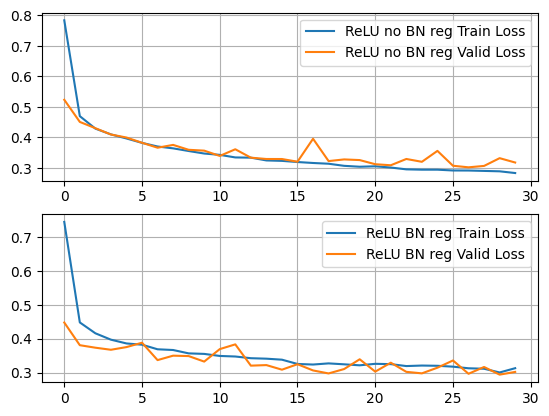

In [493]:
plt.subplot(2, 1, 1)
plt.plot(train_losses_relu, label = "ReLU no BN reg Train Loss")
plt.plot(valid_losses_relu, label = "ReLU no BN reg Valid Loss")
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(train_losses_bn, label = "ReLU BN reg Train Loss")
plt.plot(valid_losses_bn, label = "ReLU BN reg Valid Loss")
plt.legend()
plt.grid()
plt.show()

### 4. Faster optimisers

The is a range of optimisers you can use with PyTorch, from the module `torch.optim`. We only used SGD and Adam (to train the image classifier in Lectutorial 2), but you can try a range of other optimisers such as RMSProp or AdaGrad. You can find the list of optimisers available in the `torch.optim` documentation. 

To change the optmiser, you simply need to pass a different one to your training function. Be mindful that different optimisers might have different hyper-parameters you can tune. For example, you can try to change the betas values for the ADAM optimiser:

In [518]:
model = MLP_ReLU(n_inputs=X_train.shape[1], n_hidden1=200, n_hidden2=100, n_hidden3 = 50, n_outputs=1).to(device)
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999)) # Changed to ADAM optimiser
mse = nn.MSELoss()
n_epochs = 30

In [520]:
train_losses_adam, valid_losses_adam = train(model, optimizer, mse, train_loader, valid_loader, n_epochs)

Epoch 1/30, Training Loss: 0.8157, Valid Loss: 0.4386
Epoch 2/30, Training Loss: 0.4028, Valid Loss: 0.3964
Epoch 3/30, Training Loss: 0.3707, Valid Loss: 0.3561
Epoch 4/30, Training Loss: 0.3517, Valid Loss: 0.3535
Epoch 5/30, Training Loss: 0.3429, Valid Loss: 0.3424
Epoch 6/30, Training Loss: 0.3262, Valid Loss: 0.3789
Epoch 7/30, Training Loss: 0.3128, Valid Loss: 0.3211
Epoch 8/30, Training Loss: 0.3107, Valid Loss: 0.3090
Epoch 9/30, Training Loss: 0.2990, Valid Loss: 0.3090
Epoch 10/30, Training Loss: 0.2967, Valid Loss: 0.3157
Epoch 11/30, Training Loss: 0.2930, Valid Loss: 0.3394
Epoch 12/30, Training Loss: 0.2902, Valid Loss: 0.3123
Epoch 13/30, Training Loss: 0.2832, Valid Loss: 0.3067
Epoch 14/30, Training Loss: 0.2881, Valid Loss: 0.2947
Epoch 15/30, Training Loss: 0.2815, Valid Loss: 0.3107
Epoch 16/30, Training Loss: 0.2809, Valid Loss: 0.2897
Epoch 17/30, Training Loss: 0.2723, Valid Loss: 0.2929
Epoch 18/30, Training Loss: 0.2759, Valid Loss: 0.2984
Epoch 19/30, Traini

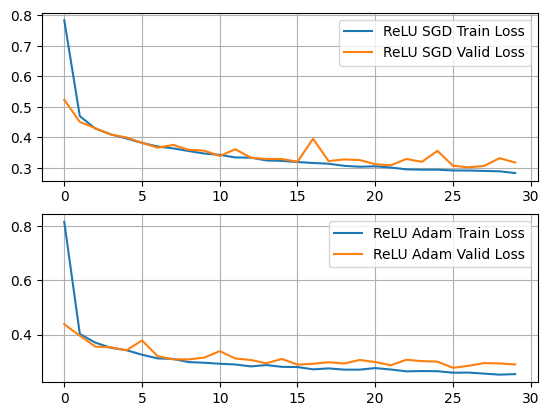

In [522]:
plt.subplot(2, 1, 1)
plt.plot(train_losses_relu, label = "ReLU SGD Train Loss")
plt.plot(valid_losses_relu, label = "ReLU SGD Valid Loss")
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(train_losses_adam, label = "ReLU Adam Train Loss")
plt.plot(valid_losses_adam, label = "ReLU Adam Valid Loss")
plt.legend()
plt.grid()
plt.show()

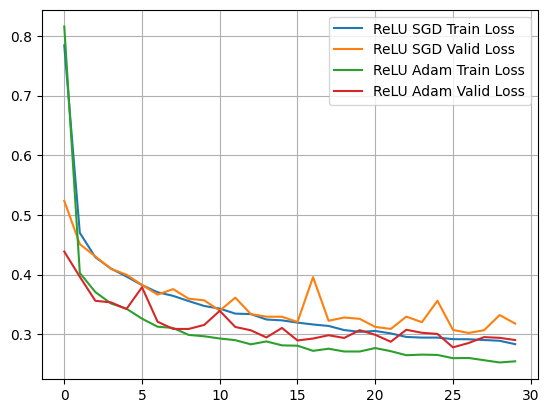

In [524]:
plt.plot(train_losses_relu, label = "ReLU SGD Train Loss")
plt.plot(valid_losses_relu, label = "ReLU SGD Valid Loss")
plt.plot(train_losses_adam, label = "ReLU Adam Train Loss")
plt.plot(valid_losses_adam, label = "ReLU Adam Valid Loss")
plt.legend()
plt.grid()
plt.show()

**TODO**: Try other optimisers and see how they behave with this model and problem.